In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.api import OLS, add_constant


In [4]:
price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()
price_data.head()


,AAPL,MSFT
Date,,
2020-01-02,72.468277,152.505661
2020-01-03,71.763733,150.606735
2020-01-06,72.335556,150.995987
2020-01-07,71.995338,149.619263
2020-01-08,73.153503,152.002457


In [6]:
# Calculate Hedge ratio 
X = add_constant(price_data["MSFT"])
y = price_data["AAPL"]

model = OLS(y, X).fit()
beta = model.params["MSFT"]
print("Beta value : ", beta)


Beta value :  0.5708428264269434


In [11]:
spread = price_data["AAPL"] - beta*price_data["MSFT"]

zscore = (spread - spread.mean())/spread.std()

In [22]:
# Generate Trading Signals
position = pd.Series(index = zscore.index, dtype = float)
position[z_score > 2] = -1
position[z_score < -2] = 1
position[(zscore <= 2) & (zscore >= -2)] = 0

position = position.ffill().fillna(0)
# ffil() means forward fill, so it fills each NaN value with the most recent value, meaning that the trading signal will hold position until signal changes


In [36]:
# Computer Strategy Returns
spread_returns = spread.diff() # change in spread

strategy_returns = position.shift(1)*spread_returns 
strategy_returns = strategy_returns.fillna(0) # first value essentially has no trading signal

# Note that we shift by 1 as we observe a signal on day t, but we can only enter the trade on t+1, so this shift prevents lookahead bias
# Then by multiplying the spread returns, we get the PnL

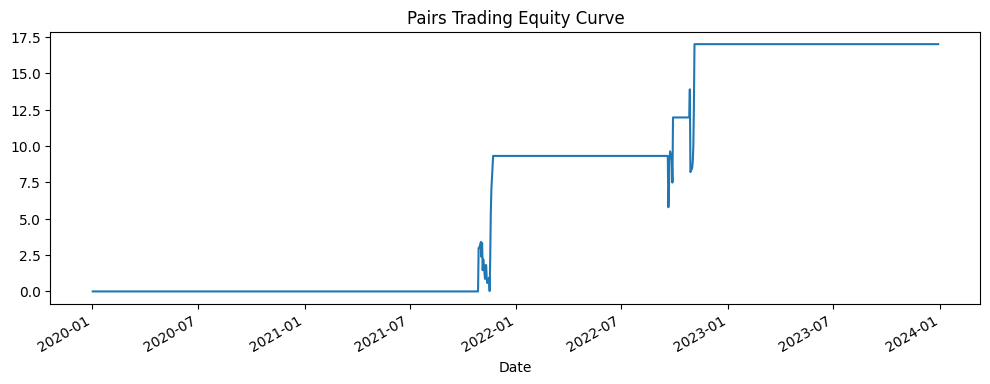

In [38]:
# Plot an equity curve (meaning the cumulative PnL)
equity_curve = strategy_returns.cumsum()

equity_curve.plot(figsize = (12,4))
plt.title("Pairs Trading Equity Curve")
plt.show()

# Note that if cointegration exists, then we should see an upward drift

In [41]:
# Calculate Sharpe Ratio
mean_return = strategy_returns.mean()
std_return = strategy_returns.std()

sharpe = (mean_return/std_return) * np.sqrt(252) # As there are 252 trading day in yr, times by root 252 to "offset" the calculations made in the mean and std

print("Annualised Sharpe Ratio: ", sharpe)

Annualised Sharpe Ratio:  0.7023483617865146


Note that this model currently ignores: 
- Transaction costs
- Slippage
- Execution delay
- Rolling hedge ratio
- Risk scaling
These will be fixed later on.